# Advanced Examples

This notebook demonstrates features beyond the basic finite-difference examples. It includes:

- a harmonic oscillator coupled to a two-level discrete system using `Ceigensolver`,
- a two-dimensional Josephson-junction problem with a mixed derivative term,
- and a comparison against the analytic Airy-function solution for $U(x)=|x|$.

The coupled solver returns wavefunctions with shape `(Enum, M, *N)`, where `M` is the dimension of the discrete basis. The standard solver supports mixed spatial derivative terms through `k_cross`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import ai_zeros, airy

import eigensolver as eg

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})


def align_phase(reference, candidate, dx):
    """Flip/phase-align a numerical eigenvector before comparing it."""
    overlap = np.sum(np.conjugate(reference) * candidate) * dx
    if np.abs(overlap) == 0:
        return candidate
    return candidate * np.conjugate(overlap) / np.abs(overlap)


def l2_error(reference, candidate, dx):
    candidate = align_phase(reference, candidate, dx)
    return np.sqrt(np.sum(np.abs(reference - candidate) ** 2) * dx)


## Harmonic oscillator coupled to a two-level system

`Ceigensolver` extends the continuous spatial problem by adding a finite-dimensional discrete basis. 

$$H = H_0 + H_1 + H_c,$$

where $H_0$ represents the nD continuous basis similar to that used in `eigensolver`, $H_1$ is a NxN matrix representing a discrete energy basis and $H_c$ represents the coupling between the discrete and continuous systems. In this example we couple a continuous basis harmonic oscillator to a qubit.

Consider the circuit:

<p align="center">
  <img src="images/Harmonic%20oscillator%20coupled%20to%20a%20qubit.png" alt="Harmonic oscillator coupled to a qubit circuit" width="650">
</p>

This gives:
$$H_0=-E_C\frac{d^2}{d\phi^2} + E_L \phi^2,$$

where $E_C = \frac{2e^2}{C_0}$ and $E_L = \Big(\frac{\hbar}{2e}\Big)^2\frac{1}{2L}$. The discrete part is a two-level system,

$$H_1=\begin{pmatrix}0&0\\0&E_q\end{pmatrix}.$$

where $E_q \approx \sqrt{E_{C,1}E_J} - \frac{E_{C,1}}{4}$. Finally the coupling hamilonian is

$$H_c=\begin{pmatrix}0&-E_g\frac{d}{d\phi}\\E_g\frac{d}{d\phi}&0\end{pmatrix},$$

where $E_g\approx\frac{4e^2 C_g}{C_0C_1}$ for $C_g<<C_0,C_1$. Note the coupling hamiltonian being momentum to momentum, $E_gn_0n_1$, coupling is passed to the solver via `k_coup`=E_g. It also supports linear position to position of the form $E_g\phi_0\phi_1$ coupling similarly via `v_coup`.

The full coupled wavefunction has two components, $\Psi_i(\phi)$ representing the $\langle \phi, i| \Psi\rangle$ projections, subject the the normalisation $\int\sum_i|\Psi_i(\phi)|\mathrm{d}\phi=1$. The derivative coupling is supplied with `k_coup`; for a scalar value, the solver builds this nearest-neighbour coupling between adjacent discrete levels and adds the Hermitian-conjugate counterpart automatically.

With $\hbar=1$, the oscillator level spacing for this convention is $2\sqrt{E_CE_L}$. The example below chooses $E_q$ to match that spacing and uses a weak derivative coupling $E_g$.


E_C = 12.5664
E_L = 37.6991
E_g = 0.3142
E_q = 43.5312
Coupled eigenvalues: [ 21.76437504  65.00273963  65.58743754 108.41142893 109.23829069
 151.84735949]


c:\Users\00095436\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\00095436\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


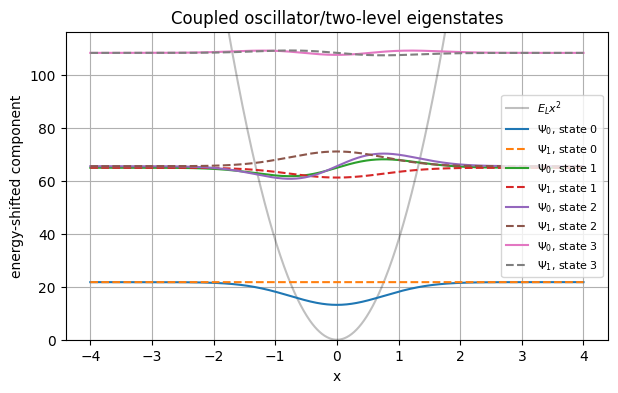

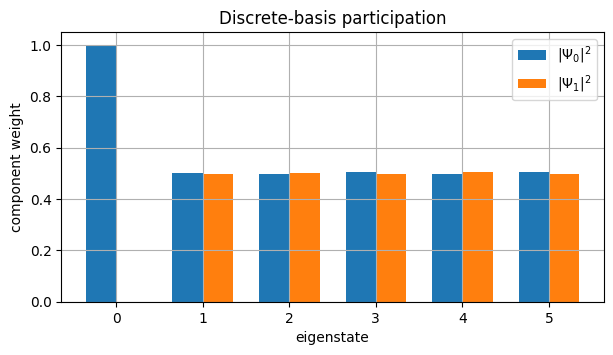

In [10]:
hbar = 1.0
GHz = 1.0

E_C = hbar * (2 * np.pi * 2.0 * GHz)
E_L = hbar * (2 * np.pi * 6.0 * GHz)
E_g = hbar * (2 * np.pi * 0.05 * GHz)

omega_osc = 2.0 * np.sqrt(E_C * E_L) / hbar
E_q = hbar * omega_osc

H1 = np.array([
    [0.0, 0.0],
    [0.0, E_q],
])

U_osc = lambda x: E_L * x**2

vals_c, vecs_c, xlists_c = eg.Ceigensolver(
    U_osc,
    H1,
    N=[801],
    domain=[(-4, 4)],
    k_diag=[E_C],
    k_coup=E_g,
    Enum=6,
    which="SA",
)

x = xlists_c[0]
wave_fun_plot_scale = 10

print(f"E_C = {E_C:.4f}")
print(f"E_L = {E_L:.4f}")
print(f"E_g = {E_g:.4f}")
print(f"E_q = {E_q:.4f}")
vals_c_plot = np.real(vals_c)
print("Coupled eigenvalues:", vals_c_plot)

plt.plot(x, U_osc(x), "k", alpha=0.25, label="$E_L x^2$")
for state in range(4):
    psi0 = np.real(vecs_c[state, 0])
    psi1 = np.real(vecs_c[state, 1])
    plt.plot(x, psi0*wave_fun_plot_scale + vals_c_plot[state], label=fr"$\Psi_0$, state {state}")
    plt.plot(x, psi1*wave_fun_plot_scale + vals_c_plot[state], "--", label=fr"$\Psi_1$, state {state}")

plt.ylim(0, vals_c_plot[3] + 8)
plt.xlabel("x")
plt.ylabel("energy-shifted component")
plt.title("Coupled oscillator/two-level eigenstates")
plt.legend(ncol=1, fontsize=8)
plt.show()

component_weight = np.sum(np.abs(vecs_c)**2, axis=2) * (x[1] - x[0])

fig, ax = plt.subplots(figsize=(7, 3.5))
width = 0.35
state_ids = np.arange(len(vals_c))
ax.bar(state_ids - width/2, component_weight[:, 0], width, label=r"$|\Psi_0|^2$")
ax.bar(state_ids + width/2, component_weight[:, 1], width, label=r"$|\Psi_1|^2$")
ax.set_xlabel("eigenstate")
ax.set_ylabel("component weight")
ax.set_title("Discrete-basis participation")
ax.legend()
plt.show()


## Fully 2D 2 coupled Josephson Junctions

The standard `eigensolver` also supports mixed spatial derivative terms through `k_cross`.  This finds eigenstates for the following circuit:

<p align="center">
  <img src="images/Coupled%20Junctions.png" alt="Two coupled Josephson junctions circuit" width="650">
</p>

This has corresponding hamitonian:

$$H=-E_{C,0}\frac{\partial^2}{\partial \phi_0^2}-E_{C,1}\frac{\partial^2}{\partial \phi_1^2}-E_g\frac{\partial^2}{\partial \phi_0\partial \phi_1}+U(\phi_0,\phi_1),$$

with

$$U(\phi_0,\phi_1)=E_{J,0}\left(1-\sin\phi_0\right)+E_{J,1}\left(1-\sin\phi_1\right).$$

As before $E_{C_i} = \frac{2e^2}{C_i}$ and $E_g\approx\frac{4e^2 C_g}{C_0C_1}$ for $C_g<<C_0,C_1$. The terms $E_{C,i}$ are included in `k_diag` and $E_g$ is represented with `k_cross={(0, 1): -E_g}`.


Eigenvalues: [32.54584917 62.36605734 62.44028682 92.2588735  96.0188141 ]


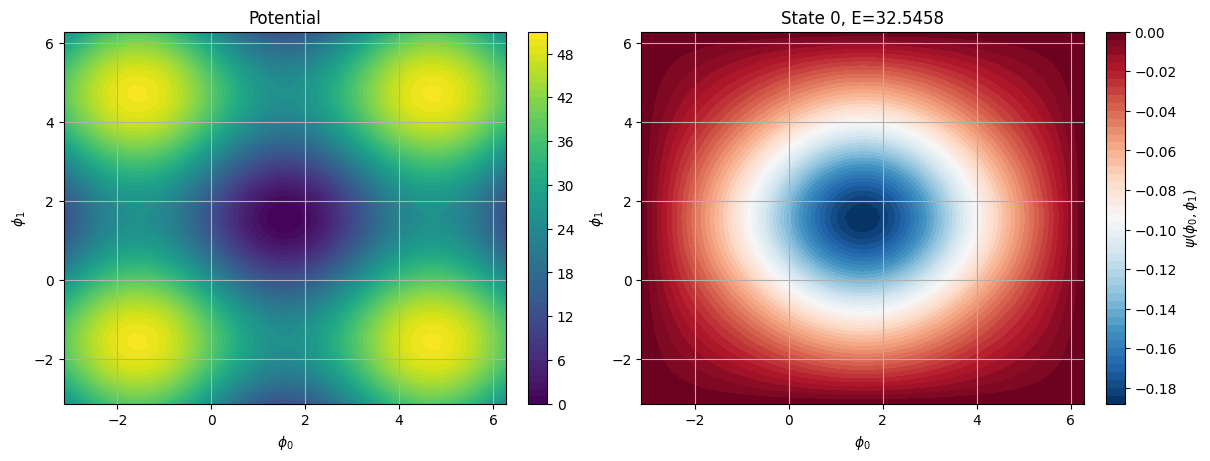

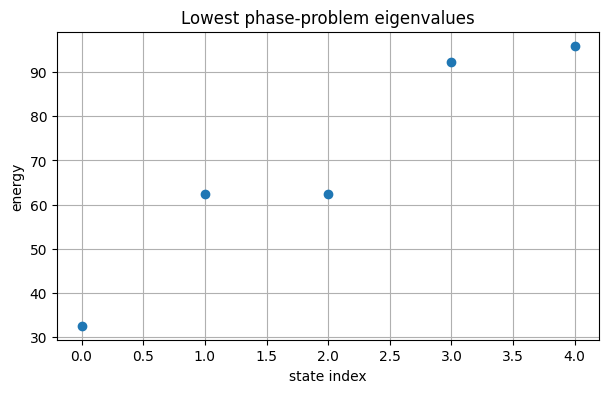

In [5]:
hbar = 1.0
GHz = 1.0

E_C0 = hbar * (2 * np.pi * 10.0 * GHz)
E_C1 = hbar * (2 * np.pi * 10.0 * GHz)
E_J0 = hbar * (2 * np.pi * 2.0 * GHz)
E_J1 = hbar * (2 * np.pi * 2.0 * GHz)
E_g = hbar * (2 * np.pi * 0.05 * GHz)


def U_phase(phi0, phi1):
    return E_J0 * (1 - np.sin(phi0)) + E_J1 * (1 - np.sin(phi1))


N_phase = 121
phase_domain = [(-np.pi, 2 * np.pi), (-np.pi, 2 * np.pi)]

vals_phase, vecs_phase, phase_lists = eg.eigensolver(
    U_phase,
    N=[N_phase, N_phase],
    domain=phase_domain,
    k_diag=[E_C0, E_C1],
    k_cross={(0, 1): -E_g},
    Enum=5,
    method="finite_difference",
    which="SA",
)

print("Eigenvalues:", vals_phase)

phi0, phi1 = phase_lists
Phi0, Phi1 = np.meshgrid(phi0, phi1, indexing="ij")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

pot = ax[0].contourf(Phi0, Phi1, U_phase(Phi0, Phi1), levels=50, cmap="viridis")
ax[0].set_xlabel(r"$\phi_0$")
ax[0].set_ylabel(r"$\phi_1$")
ax[0].set_title("Potential")
fig.colorbar(pot, ax=ax[0])

state_to_plot = 0
psi_phase_plot = np.real(vecs_phase[state_to_plot])
wf = ax[1].contourf(Phi0, Phi1, psi_phase_plot, levels=50, cmap="RdBu_r")
ax[1].set_xlabel(r"$\phi_0$")
ax[1].set_ylabel(r"$\phi_1$")
ax[1].set_title(f"State {state_to_plot}, E={vals_phase[state_to_plot]:.4f}")
fig.colorbar(wf, ax=ax[1], label=r"$\psi(\phi_0,\phi_1)$")

plt.show()

plt.plot(vals_phase, "o")
plt.xlabel("state index")
plt.ylabel("energy")
plt.title("Lowest phase-problem eigenvalues")
plt.show()


## The Airy problem: $U(x)=|x|$

For

$$H=-k\frac{d^2}{dx^2}+|x|,$$

the decaying solutions are Airy functions. Even states are fixed by zeros of $\mathrm{Ai}'$, and odd states by zeros of $\mathrm{Ai}$. This gives a convenient analytic reference for comparing numerical methods.

Discontinuous and non-differentiable potentials can reduce the accuracy of a finite-difference discretisation, especially when high-precision eigenvectors are required. The finite element method provides an alternative discretisation that can behave better near non-smooth points.

The generic solver exposes two method choices: `method="finite_difference"`, which is the default, and `method="FEM"`, which uses the scikit-fem backend. The FEM backend also accepts `intorder`, the integration order used in discretising the pde.


In [2]:
def airy_abs_potential_energies(n_states, k=1.0):
    n_need = n_states // 2 + 3
    ai_zero_vals, aip_zero_vals, _, _ = ai_zeros(n_need)

    states = []
    for n, E in enumerate(-aip_zero_vals * k**(1/3)):
        states.append((E, "even", n))
    for n, E in enumerate(-ai_zero_vals * k**(1/3)):
        states.append((E, "odd", n))
    states.sort(key=lambda item: item[0])
    return states[:n_states]


def airy_abs_potential_state(x, E, parity="even", k=1.0):
    z = (np.abs(x) - E) / k**(1/3)
    psi = airy(z)[0]
    if parity == "odd":
        psi = np.sign(x) * psi
        psi[np.isclose(x, 0)] = 0.0
    elif parity != "even":
        raise ValueError("parity must be 'even' or 'odd'")
    norm = np.sqrt(np.trapz(np.abs(psi)**2, x))
    return psi / norm


states = airy_abs_potential_energies(5)


Airy energies:         [1.01879297 2.33810741 3.24819758 4.08794944 4.82009921]
Finite difference:     [1.01868904 2.33802541 3.24801158 4.08769874 4.81973196]
FD energy errors:      [-1.03929564e-04 -8.20028007e-05 -1.86005650e-04 -2.50703705e-04
 -3.67253229e-04]
FEM:                   [1.01882326 2.3381894  3.24836044 4.08820007 4.82045075]
FEM energy errors:     [3.02878490e-05 8.19939611e-05 1.62856104e-04 2.50630603e-04
 3.51543708e-04]


C:\Users\00095436\AppData\Local\Temp\ipykernel_31540\903485620.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(psi)**2, x))


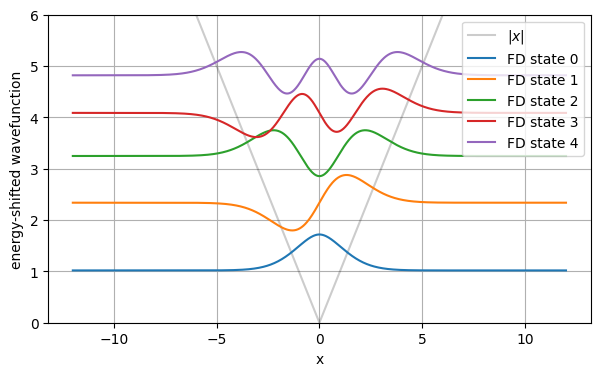

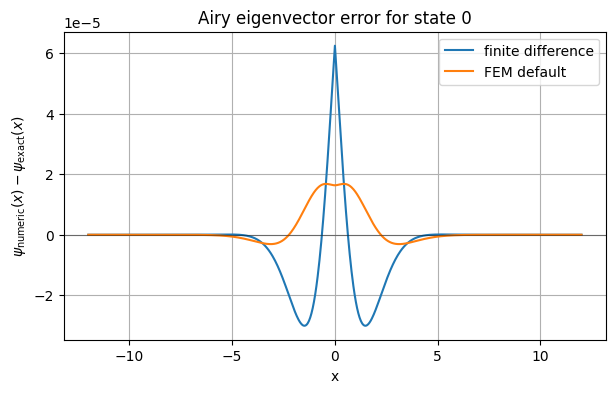

In [3]:
U_abs = lambda x: np.abs(x)

common = dict(
    U=U_abs,
    N=[801],
    domain=[(-12, 12)],
    k_diag=[1],
    Enum=5,
    which="SA",
)

vals_fd, vecs_fd, xlists_fd = eg.eigensolver(method="finite_difference", **common)
vals_fem, vecs_fem, xlists_fem = eg.eigensolver(method="FEM", intorder=None, **common)

x = xlists_fd[0]
dx = x[1] - x[0]
analytic_vals = np.array([s[0] for s in states])

print("Airy energies:        ", analytic_vals)
print("Finite difference:    ", vals_fd)
print("FD energy errors:     ", vals_fd - analytic_vals)
print("FEM:                  ", vals_fem)
print("FEM energy errors:    ", vals_fem - analytic_vals)

plt.plot(x, U_abs(x), "k", alpha=0.2, label="$|x|$")
for i, (E, parity, idx) in enumerate(states):
    psi = airy_abs_potential_state(x, E, parity=parity)
    psi_fd = align_phase(psi, vecs_fd[i], dx)
    plt.plot(x, psi_fd + vals_fd[i], label=f"FD state {i}")
plt.ylim(0, 6)
plt.xlabel("x")
plt.ylabel("energy-shifted wavefunction")
plt.legend()
plt.show()

state_to_compare = 0
E, parity, idx = states[state_to_compare]
psi_exact = airy_abs_potential_state(x, E, parity=parity)

plt.plot(x, align_phase(psi_exact, vecs_fd[state_to_compare], dx) - psi_exact, label="finite difference")
plt.plot(x, align_phase(psi_exact, vecs_fem[state_to_compare], dx) - psi_exact, label="FEM default")
plt.axhline(0.0, color="k", linewidth=0.8, alpha=0.4)
plt.xlabel("x")
plt.ylabel(r"$\psi_\mathrm{numeric}(x)-\psi_\mathrm{exact}(x)$")
plt.title(f"Airy eigenvector error for state {state_to_compare}")
plt.legend()
plt.show()
